# Task 2 - Sentiment Analysis

## Cell 1: Environment Setup & Core Imports

In [1]:
%%capture
!pip install transformers datasets evaluate scikit-learn seaborn plotly wordcloud nbformat

import os, re, zipfile, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud, STOPWORDS

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
COLOR_MAP = {'negative': '#e74c3c', 'neutral': '#bdc3c7', 'positive': '#2ecc71'}

print("🚀 Core Architecture Loaded Successfully!")

## Cell 2: Secure Data Acquisition

In [3]:
!curl -L -s -o sentiment_dataset.zip https://www.kaggle.com/api/v1/datasets/download/abhi8923shriv/sentiment-analysis-dataset

os.makedirs("data", exist_ok=True)
with zipfile.ZipFile("sentiment_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

# Correctly specify train.csv and test.csv as these typically contain 'text' and 'sentiment' columns
train_path = os.path.join("data", "train.csv")
test_path = os.path.join("data", "test.csv")

df_tr = pd.read_csv(train_path, encoding='latin-1').dropna(subset=['text', 'sentiment'])
df_te  = pd.read_csv(test_path, encoding='latin-1').dropna(subset=['text', 'sentiment'])

def normalize_sentiment(val):
    val = str(val).lower().strip()
    return 'positive' if val in ['positive', '1'] else 'negative' if val in ['negative', '0'] else 'neutral'

df_tr['label'] = df_tr['sentiment'].apply(normalize_sentiment)
df_te['label'] = df_te['sentiment'].apply(normalize_sentiment)

print(f"📊 Dataset Loaded: {len(df_tr):,} Train | {len(df_te):,} Test")

📊 Dataset Loaded: 27,480 Train | 3,534 Test


## Cell 3: Advanced EDA - Text Topography & Unique Vocabulary

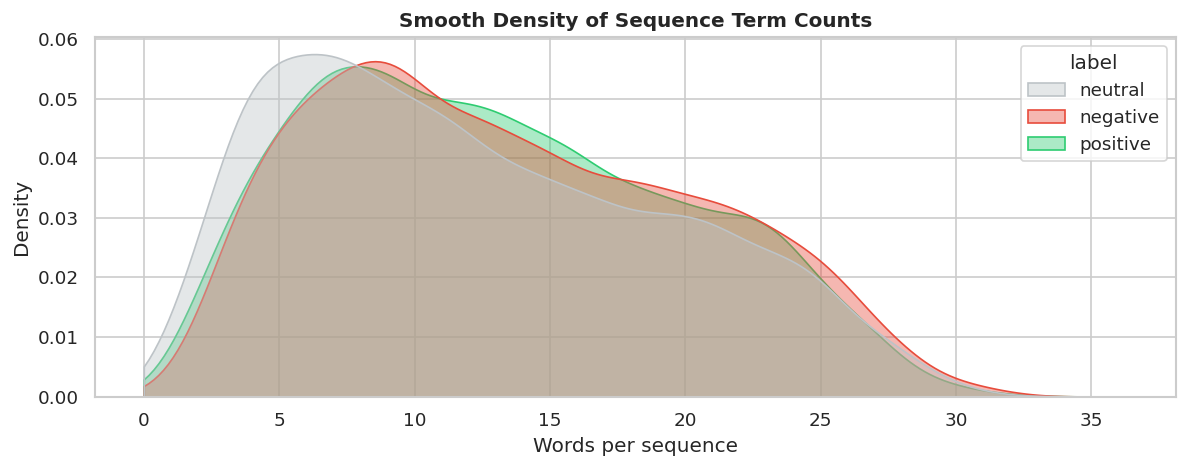

In [4]:
# 1. Interactive Class Distributions
fig = px.pie(df_tr, names='label', title="Dataset Target Imbalance", color='label',
             color_discrete_map=COLOR_MAP, hole=0.3, template="plotly_white")
fig.update_traces(textinfo='percent+label', marker=dict(line=dict(color='#000000', width=1)))
fig.show()

# 2. KDE Topographies for Word Length
df_tr['word_len'] = df_tr['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_tr, x='word_len', hue='label', palette=COLOR_MAP,
            fill=True, common_norm=False, alpha=0.4, clip=(0, 40))
plt.title("Smooth Density of Sequence Term Counts", fontweight='bold')
plt.xlabel("Words per sequence"); plt.ylabel("Density")
plt.tight_layout()
plt.show()

# 3. Unique Vocabulary Size per Class
vocab_data = []
for label in ['negative', 'neutral', 'positive']:
    text_blob = " ".join(df_tr[df_tr['label'] == label]['text'].astype(str).str.lower())
    words = set(re.sub(r'[^a-z\s]', '', text_blob).split())
    vocab_data.append({'Sentiment': label.capitalize(), 'Unique Words': len(words)})

vocab_df = pd.DataFrame(vocab_data)
fig = px.bar(vocab_df, x='Sentiment', y='Unique Words', color='Sentiment',
             color_discrete_map={'Negative': COLOR_MAP['negative'], 'Neutral': COLOR_MAP['neutral'], 'Positive': COLOR_MAP['positive']},
             title="Unique Lexicon Volume per Class", text_auto=True, template="plotly_white")
fig.show()

## Cell 4: Advanced EDA - Semantic Lexicons (N-grams)

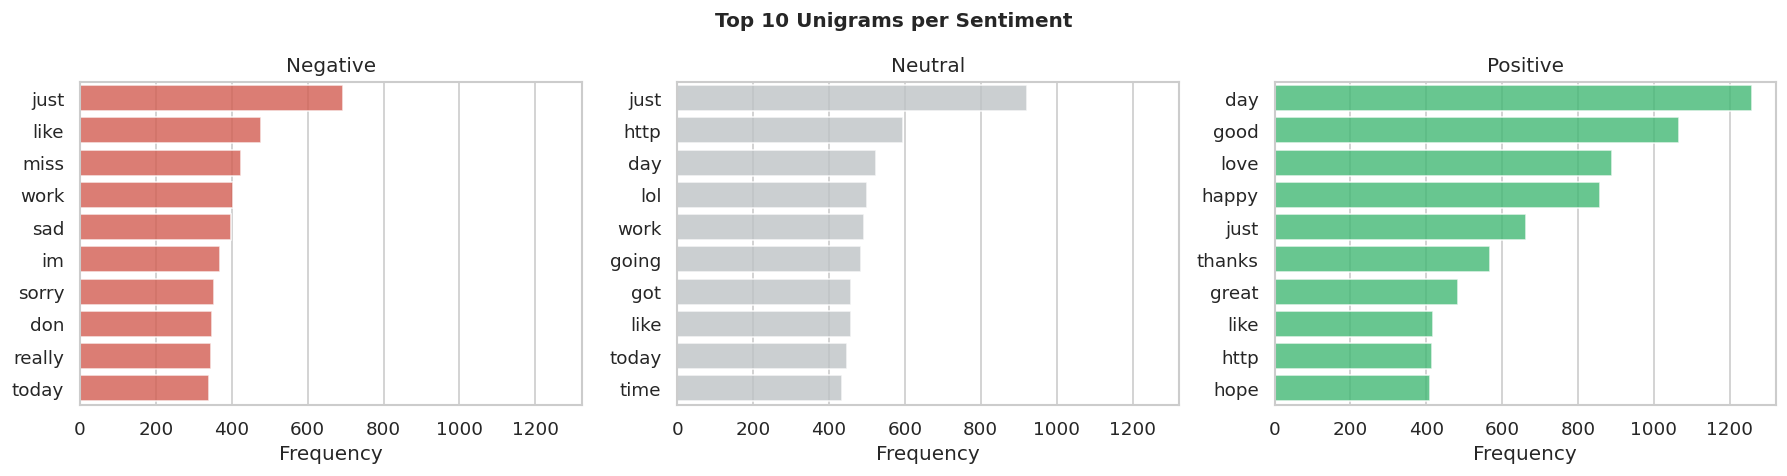

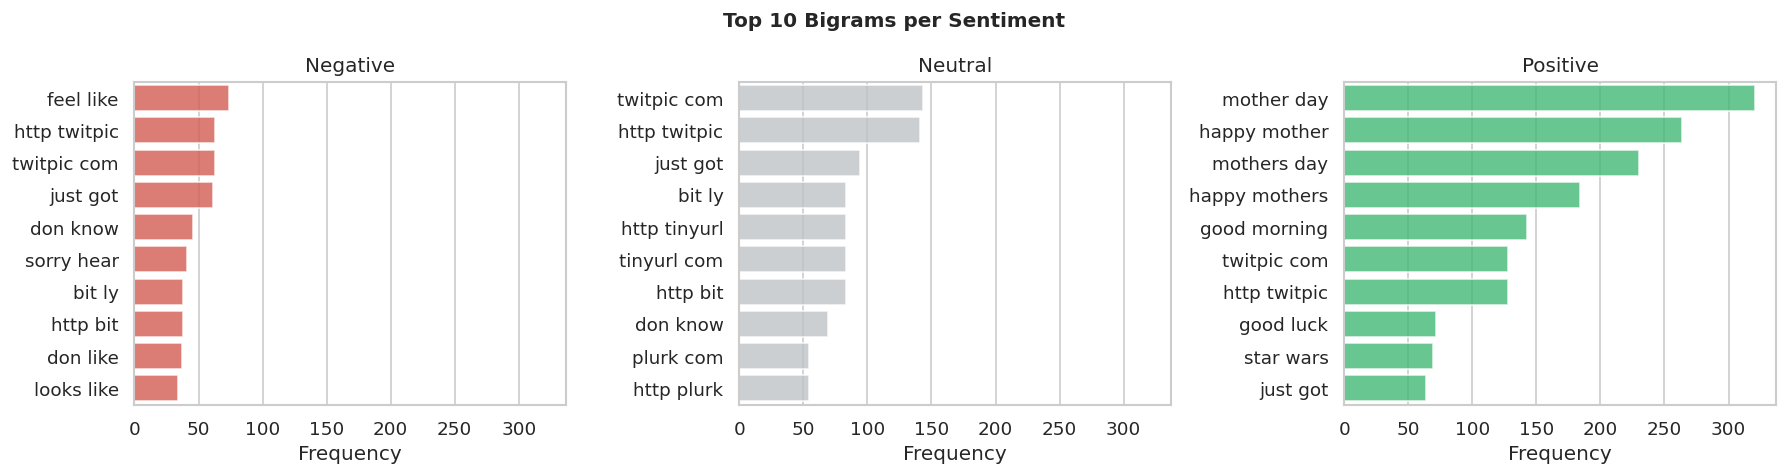

In [5]:
def plot_top_ngrams(df, n=1, top_k=10):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    fig.suptitle(f"Top {top_k} {'Unigrams' if n==1 else 'Bigrams'} per Sentiment", fontweight='bold')

    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=1000)
    for ax, sentiment in zip(axes, ['negative', 'neutral', 'positive']):
        corpus = df[df['label'] == sentiment]['text'].astype(str)
        if len(corpus) == 0: continue

        matrix = vec.fit_transform(corpus)
        counts = matrix.sum(axis=0).A1
        vocab = vec.get_feature_names_out()

        top_indices = counts.argsort()[::-1][:top_k]
        sns.barplot(x=counts[top_indices], y=vocab[top_indices], ax=ax, color=COLOR_MAP[sentiment], alpha=0.8)
        ax.set_title(sentiment.capitalize())
        ax.set_xlabel("Frequency")

    plt.tight_layout()
    plt.show()

plot_top_ngrams(df_tr, n=1)
plot_top_ngrams(df_tr, n=2)

## Cell 5: Data Pipeline & Baseline Anchor (TF-IDF + LR)

In [6]:
def scrub(text):
    text = re.sub(r'http\S+|www\S+|@[^\s]+', '', str(text).lower())
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df_tr['clean'] = df_tr['text'].apply(scrub)
df_te['clean'] = df_te['text'].apply(scrub)

df_base_tr = df_tr.sample(8000, random_state=42)
df_base_te = df_te.sample(2000, random_state=42)

vectorizer = TfidfVectorizer(max_features=15000, sublinear_tf=True)
X_tr = vectorizer.fit_transform(df_base_tr['clean'])
X_te = vectorizer.transform(df_base_te['clean'])

baseline = LogisticRegression(class_weight='balanced', max_iter=400)
baseline.fit(X_tr, df_base_tr['label'])
preds_base = baseline.predict(X_te)

base_acc = accuracy_score(df_base_te['label'], preds_base)
base_f1 = f1_score(df_base_te['label'], preds_base, average='macro')

print("--- TF-IDF Baseline ---")
print(classification_report(df_base_te['label'], preds_base))

--- TF-IDF Baseline ---
              precision    recall  f1-score   support

    negative       0.60      0.68      0.64       550
     neutral       0.63      0.59      0.61       821
    positive       0.74      0.72      0.73       629

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000



## Cell 6: HuggingFace Tokenization Pipeline

In [7]:
import torch
from datasets import Dataset
from transformers import AutoTokenizer

MODEL_PATH = 'distilbert-base-uncased'
MAX_SEQ = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
LMAP = {'negative': 0, 'neutral': 1, 'positive': 2}
RMAP = {v: k for k, v in LMAP.items()}

df_base_tr['label_id'] = df_base_tr['label'].map(LMAP)
df_base_te['label_id'] = df_base_te['label'].map(LMAP)

ds_tr = Dataset.from_pandas(df_base_tr[['clean', 'label_id']])
ds_te = Dataset.from_pandas(df_base_te[['clean', 'label_id']])

def format_tokens(batch):
    return tokenizer(batch['clean'], padding='max_length', truncation=True, max_length=MAX_SEQ)

hft_train = ds_tr.map(format_tokens, batched=True).remove_columns(['clean', '__index_level_0__']).with_format("torch")
hft_test = ds_te.map(format_tokens, batched=True).remove_columns(['clean', '__index_level_0__']).with_format("torch")

hft_train = hft_train.rename_column("label_id", "labels")
hft_test = hft_test.rename_column("label_id", "labels")
print("🔥 Token Tensors Ready.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

🔥 Token Tensors Ready.


## Cell 7: Imbalance-Aware Trainer Configuration

In [19]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.utils.class_weight import compute_class_weight
import evaluate

weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=df_base_tr['label_id'].values)
class_weights = torch.tensor(weights, dtype=torch.float)

class RobustTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH, num_labels=3, id2label=RMAP, label2id=LMAP)
acc_metric = evaluate.load("accuracy")

def computer(pred):
    return acc_metric.compute(predictions=np.argmax(pred.predictions, axis=1), references=pred.label_ids)

args = TrainingArguments(
    output_dir="./transformer_run",
    num_train_epochs=10,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    lr_scheduler_type = 'cosine',
    load_best_model_at_end=True,
    weight_decay=0.01,
    warmup_ratio = 0.2,
    fp16=True,
    report_to="none"
)

trainer = RobustTrainer(model=model, args=args, train_dataset=hft_train, eval_dataset=hft_test, compute_metrics=computer)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## Cell 8: Execute Transformer Fine-Tuning

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.656421,0.726500
2,0.783839,0.597493,0.730000
3,0.783839,0.586764,0.749500
4,0.401884,0.650416,0.753000
5,0.401884,0.738364,0.752500
6,0.189332,0.841098,0.758500
7,0.189332,0.964126,0.758000
8,0.093614,1.066074,0.755500
9,0.093614,1.070649,0.757500
10,0.064362,1.075567,0.758000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


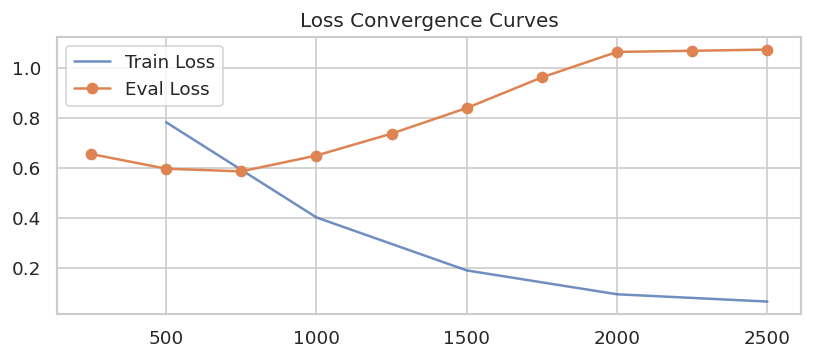

In [20]:
trainer.train()

history = trainer.state.log_history
tr_loss = [x for x in history if 'loss' in x]
ev_loss = [x for x in history if 'eval_loss' in x]

if tr_loss and ev_loss:
    plt.figure(figsize=(8,3))
    plt.plot([x['step'] for x in tr_loss], [x['loss'] for x in tr_loss], label='Train Loss', alpha=0.8)
    plt.plot([x['step'] for x in ev_loss], [x['eval_loss'] for x in ev_loss], marker='o', label='Eval Loss')
    plt.title("Loss Convergence Curves")
    plt.legend(); plt.show()

## Cell 9: High-Definition Evaluation Portfolio

=== DISTILBERT PERFORMANCE ===
              precision    recall  f1-score   support

    negative       0.70      0.82      0.76       550
     neutral       0.75      0.65      0.70       821
    positive       0.79      0.82      0.80       629

    accuracy                           0.75      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.75      0.75      0.75      2000



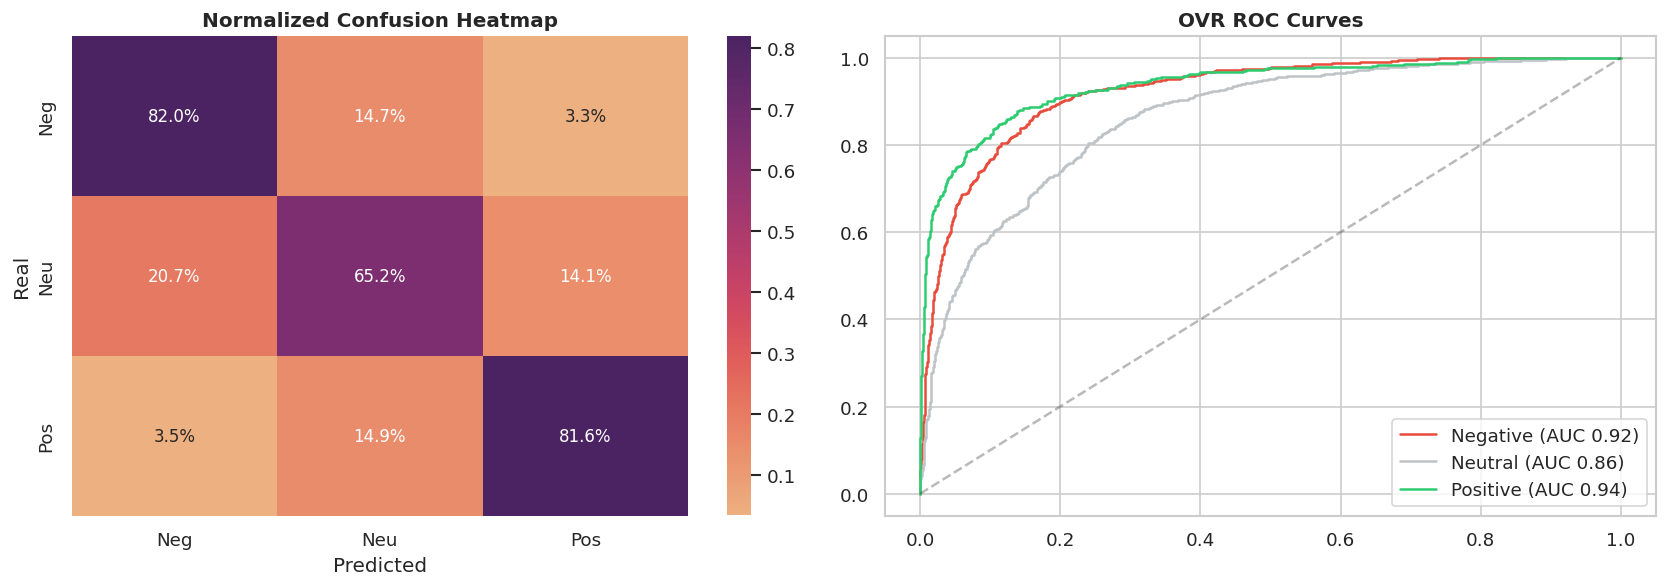

In [21]:
out = trainer.predict(hft_test)
y_pred = np.argmax(out.predictions, axis=1)
y_prob = torch.softmax(torch.tensor(out.predictions), dim=1).numpy()
y_true = out.label_ids

tf_acc = accuracy_score(y_true, y_pred)
tf_f1 = f1_score(y_true, y_pred, average='macro')

print("=== DISTILBERT PERFORMANCE ===")
print(classification_report(y_true, y_pred, target_names=['negative', 'neutral', 'positive']))

# Precision/Recall granular metric extraction
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
metrics_df = pd.DataFrame({'Precision': p, 'Recall': r, 'F1': f}, index=['Negative', 'Neutral', 'Positive']).reset_index()
fig_m = px.bar(metrics_df.melt(id_vars='index'), x='index', y='value', color='variable', barmode='group',
               title="Granular Classification Metrics per Class", template="plotly_white")
fig_m.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalized Heatmap
cm = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.1%', cmap='flare', ax=axes[0],
            xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
axes[0].set_title("Normalized Confusion Heatmap", fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicted')

# OVR ROC Curves
y_bin = label_binarize(y_true, classes=[0,1,2])
for i, sen in enumerate(['negative', 'neutral', 'positive']):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    axes[1].plot(fpr, tpr, label=f"{sen.capitalize()} (AUC {roc_auc_score(y_bin[:, i], y_prob[:, i]):.2f})", color=COLOR_MAP[sen])

axes[1].plot([0,1],[0,1], 'k--', alpha=0.3)
axes[1].set_title("OVR ROC Curves", fontweight='bold')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

## Cell 10: Deep Error Diagnostics (Confidence & Calibration)

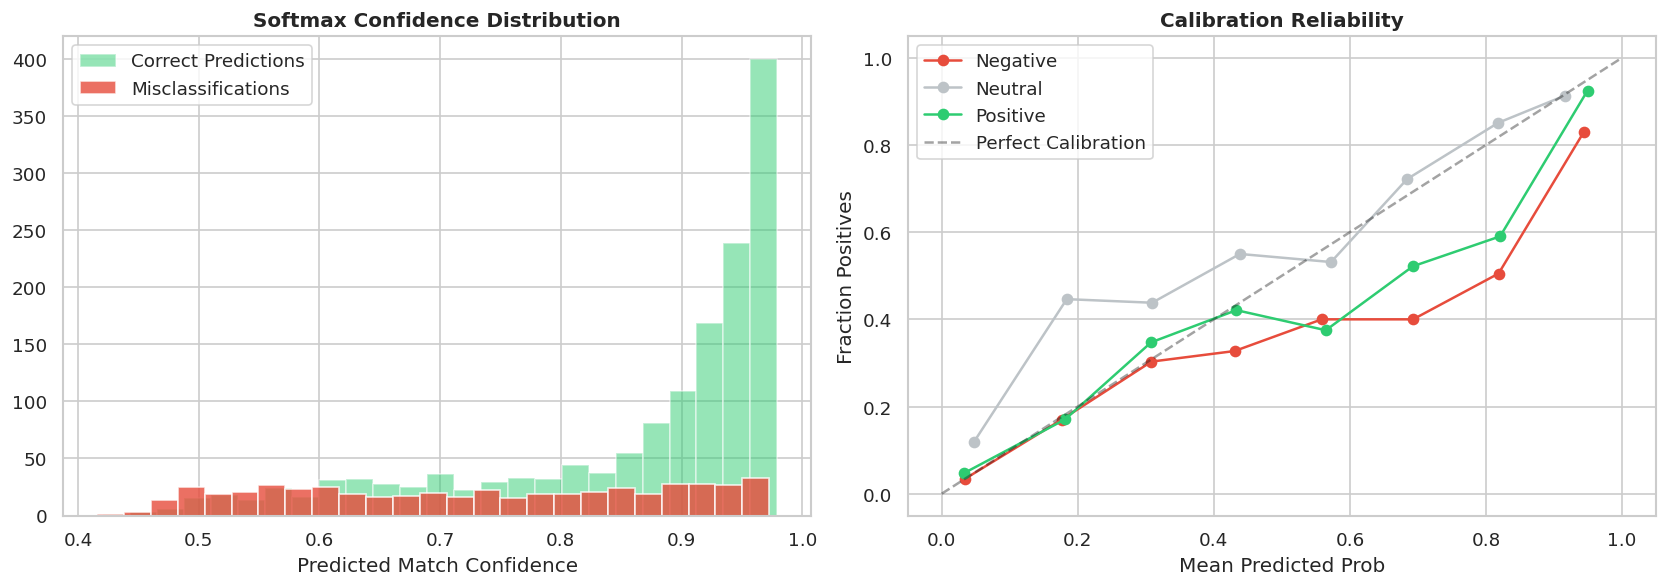

🚨 TOP 5 HIGHEST CONFIDENCE ERRORS:
--------------------------------------------------
[NEUTRAL misclassified as NEGATIVE] - 97.3%
"My head hurts....  Can wait to see the new photoshoot!!!!!!!"

[NEUTRAL misclassified as NEGATIVE] - 97.2%
"Watching ET today!  <3 Supposed to have a clip from New Moon  Hating Drag Me To Hell"

[NEUTRAL misclassified as NEGATIVE] - 97.1%
"Bored, making a mothers day card"

[NEUTRAL misclassified as POSITIVE] - 97.1%
"My younger sister flies in next week for a two week visit. So blessed to look forward to seeing family members visit."

[NEUTRAL misclassified as NEGATIVE] - 97.0%
"Huge headache...goodnight!!"



In [22]:
max_conf = y_prob.max(axis=1)
is_correct = (y_pred == y_true)

# Calibration & Confidence distribution mapping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_conf[is_correct], bins=25, alpha=0.5, color=COLOR_MAP['positive'], label='Correct Predictions')
axes[0].hist(max_conf[~is_correct], bins=25, alpha=0.8, color=COLOR_MAP['negative'], label='Misclassifications')
axes[0].set_title("Softmax Confidence Distribution", fontweight='bold')
axes[0].set_xlabel("Predicted Match Confidence"); axes[0].legend()

for i, sen in enumerate(['negative', 'neutral', 'positive']):
    frac_pos, mean_pred = calibration_curve(y_bin[:, i], y_prob[:, i], n_bins=8)
    axes[1].plot(mean_pred, frac_pos, marker='o', label=sen.capitalize(), color=COLOR_MAP[sen])

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect Calibration')
axes[1].set_title("Calibration Reliability", fontweight='bold')
axes[1].set_xlabel("Mean Predicted Prob"); axes[1].set_ylabel("Fraction Positives"); axes[1].legend()
plt.tight_layout()
plt.show()

# Top 5 Absolute Worst Mistakes
errors_df = pd.DataFrame({
    'text': df_base_te['text'].values,
    'true_label': [RMAP[t] for t in y_true],
    'predicted_label': [RMAP[p] for p in y_pred],
    'confidence': max_conf
})
mistakes = errors_df[errors_df['true_label'] != errors_df['predicted_label']].sort_values('confidence', ascending=False)

print("🚨 TOP 5 HIGHEST CONFIDENCE ERRORS:")
print("-" * 50)
for _, row in mistakes.head(5).iterrows():
    print(f"[{row['true_label'].upper()} misclassified as {row['predicted_label'].upper()}] - {row['confidence']:.1%}")
    print(f"\"{row['text']}\"\n")

## Cell 11: Real-Time Interactive Inference

In [23]:
def semantic_tester(text):
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    toks = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_SEQ).to(dev)
    with torch.no_grad():
        out = model(**toks).logits
    probs = torch.softmax(out, dim=1).cpu().numpy()[0]

    pred_class = RMAP[np.argmax(probs)]
    conf = np.max(probs) * 100

    color = "🟢" if pred_class == "positive" else "🔴" if pred_class == "negative" else "⚪"
    print(f"\n{color} {pred_class.upper()} [{conf:.1f}% confidence]")
    print(f"     \"{text}\"")

print("--- Real Time Engine Started ---")
semantic_tester("This is an unmitigated disaster, absolutely terrible experience.")
semantic_tester("I mean it was generally alright. Nothing completely spectacular but decent.")
semantic_tester("Exquisitely beautiful layout, breathtaking service! I'm completely in awe.")

--- Real Time Engine Started ---

🔴 NEGATIVE [96.6% confidence]
     "This is an unmitigated disaster, absolutely terrible experience."

⚪ NEUTRAL [47.5% confidence]
     "I mean it was generally alright. Nothing completely spectacular but decent."

🟢 POSITIVE [96.3% confidence]
     "Exquisitely beautiful layout, breathtaking service! I'm completely in awe."
